# Predictive Maintenance using NASA CMAPSS Dataset

## Import Libraries



In [1]:
import pandas as pd
import numpy as np

## Load Dataset

In [2]:
columns = ['engine_id', 'cycle']

columns += [f'operational_setting_{i}' for i in range(1,4)]

columns += [f'sensor_{i}' for i in range(1,22)]

df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)

df = df.iloc[:, :26]

df.columns = columns

df.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Dataset Overview

In [3]:
print("Shape:", df.shape)

Shape: (20631, 26)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   engine_id              20631 non-null  int64  
 1   cycle                  20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   sensor_1               20631 non-null  float64
 6   sensor_2               20631 non-null  float64
 7   sensor_3               20631 non-null  float64
 8   sensor_4               20631 non-null  float64
 9   sensor_5               20631 non-null  float64
 10  sensor_6               20631 non-null  float64
 11  sensor_7               20631 non-null  float64
 12  sensor_8               20631 non-null  float64
 13  sensor_9               20631 non-null  float64
 14  sensor_10              20631 non-null  float64
 15  se

In [5]:
df.describe()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


## Create Remaining Useful Life (RUL)

In [6]:
max_cycle = df.groupby('engine_id')['cycle'].max().reset_index()

max_cycle.columns = ['engine_id', 'max_cycle']

df = df.merge(max_cycle, on='engine_id')

df['RUL'] = df['max_cycle'] - df['cycle']

df.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [7]:
print("Number of Engines:", df['engine_id'].nunique())

Number of Engines: 100


In [8]:
df.groupby('engine_id')['cycle'].max().head()

,cycle
engine_id,
1,192
2,287
3,179
4,189
5,269


In [9]:
df['RUL'].describe()

,RUL
count,20631.000000
mean,107.807862
std,68.880990
min,0.000000
25%,51.000000
50%,103.000000
75%,155.000000
max,361.000000


## Data Quality Analysis

In [11]:
df.isnull().sum()

,0
engine_id,0
cycle,0
operational_setting_1,0
operational_setting_2,0
operational_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [12]:
variance = df.var(numeric_only=True)

variance.sort_values()

,0
operational_setting_3,0.000000e+00
sensor_18,0.000000e+00
sensor_19,0.000000e+00
sensor_16,2.422479e-28
sensor_10,2.172333e-25
sensor_5,1.152399e-23
sensor_1,4.273435e-21
operational_setting_2,8.588541e-08
sensor_6,1.929279e-06
operational_setting_1,4.784340e-06


In [13]:
constant_cols = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)

print("Constant Columns:")
print(constant_cols)

Constant Columns:
['operational_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [14]:
corr = df.corr(numeric_only=True)

rul_corr = corr["RUL"].sort_values(ascending=False)

rul_corr

,RUL
RUL,1.000000
sensor_12,0.671983
sensor_7,0.657223
sensor_21,0.635662
sensor_20,0.629428
max_cycle,0.363152
engine_id,0.078753
operational_setting_2,-0.001948
operational_setting_1,-0.003198
sensor_6,-0.128348


## Exploratory Data Analysis

### Univariate Analysis

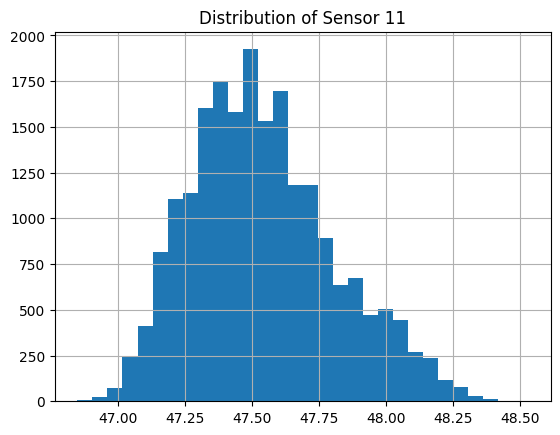

In [15]:
df['sensor_11'].hist(bins=30)

plt.title("Distribution of Sensor 11")

plt.show()

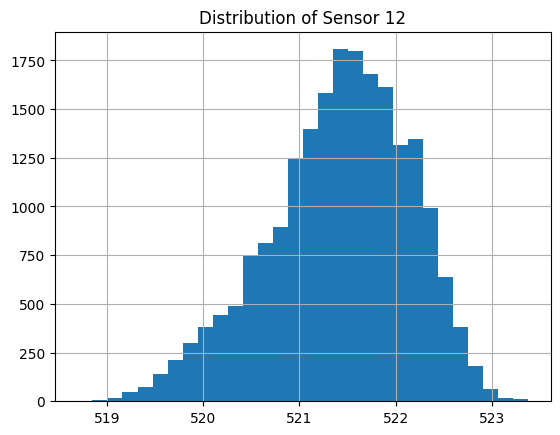

In [16]:
df['sensor_12'].hist(bins=30)

plt.title("Distribution of Sensor 12")

plt.show()

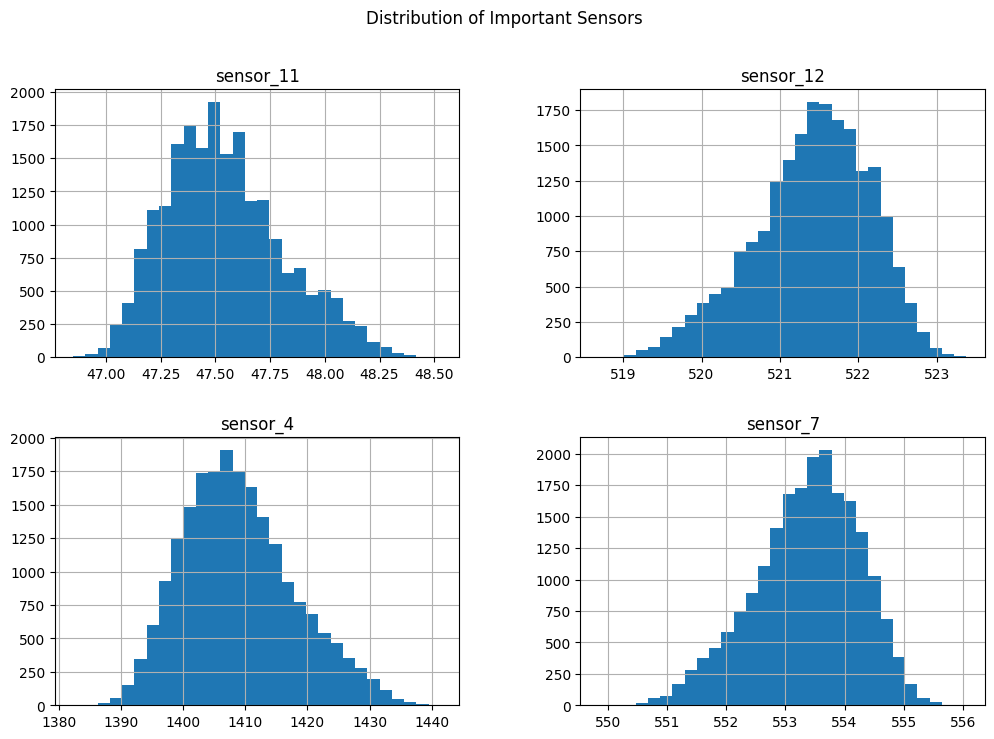

In [17]:
important_sensors = [
    'sensor_11',
    'sensor_12',
    'sensor_4',
    'sensor_7'
]

df[important_sensors].hist(
    figsize=(12,8),
    bins=30
)

plt.suptitle("Distribution of Important Sensors")

plt.show()

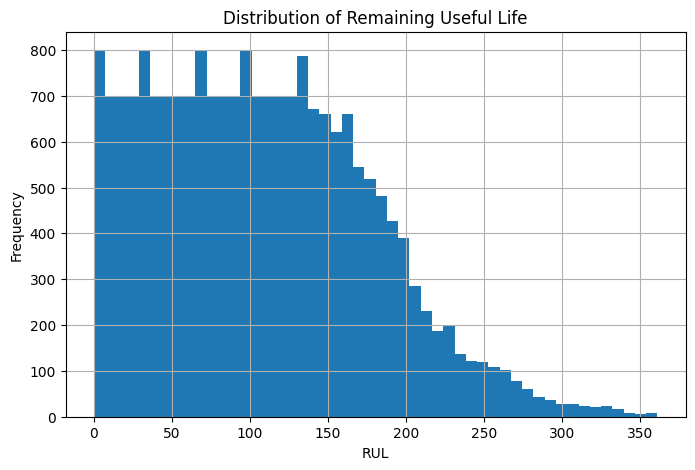

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['RUL'].hist(bins=50)

plt.title("Distribution of Remaining Useful Life")

plt.xlabel("RUL")

plt.ylabel("Frequency")

plt.show()

### Bivariate Analysis

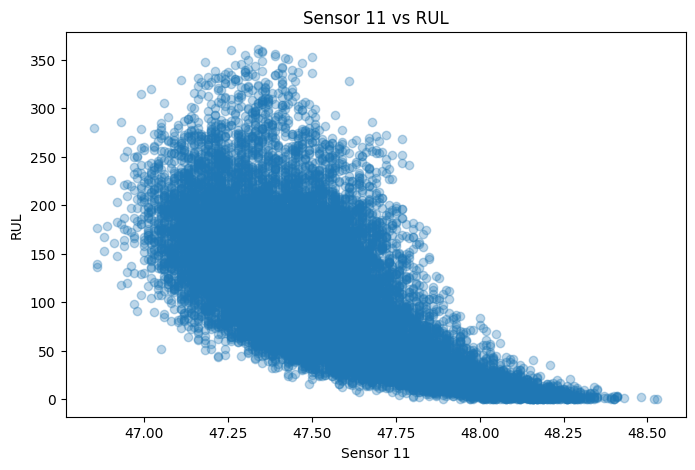

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['sensor_11'],
    df['RUL'],
    alpha=0.3
)

plt.xlabel("Sensor 11")
plt.ylabel("RUL")

plt.title("Sensor 11 vs RUL")

plt.show()

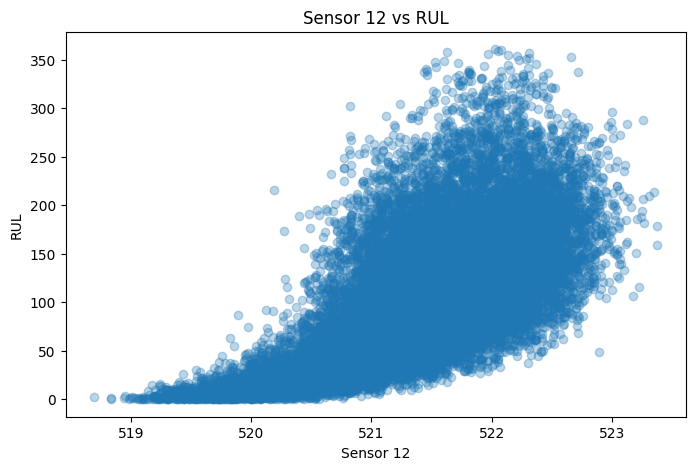

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['sensor_12'],
    df['RUL'],
    alpha=0.3
)

plt.xlabel("Sensor 12")
plt.ylabel("RUL")

plt.title("Sensor 12 vs RUL")

plt.show()

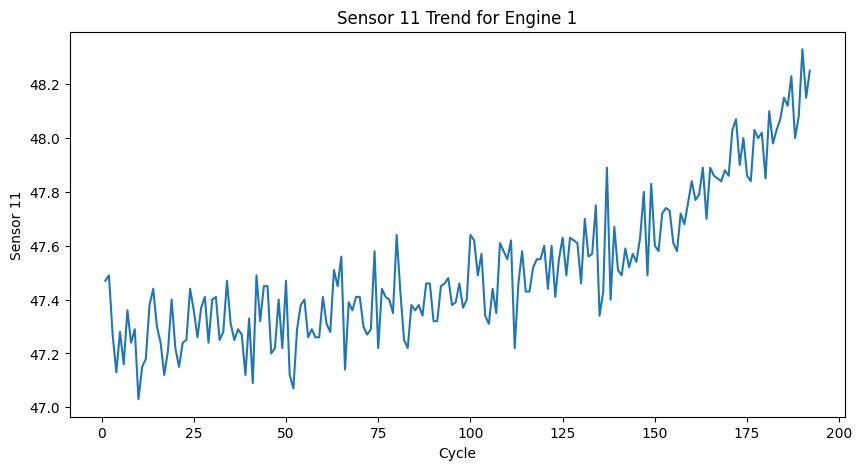

In [20]:
engine_1 = df[df['engine_id'] == 1]

plt.figure(figsize=(10,5))

plt.plot(
    engine_1['cycle'],
    engine_1['sensor_11']
)

plt.xlabel("Cycle")
plt.ylabel("Sensor 11")

plt.title("Sensor 11 Trend for Engine 1")

plt.show()

### Multivariate Analysis

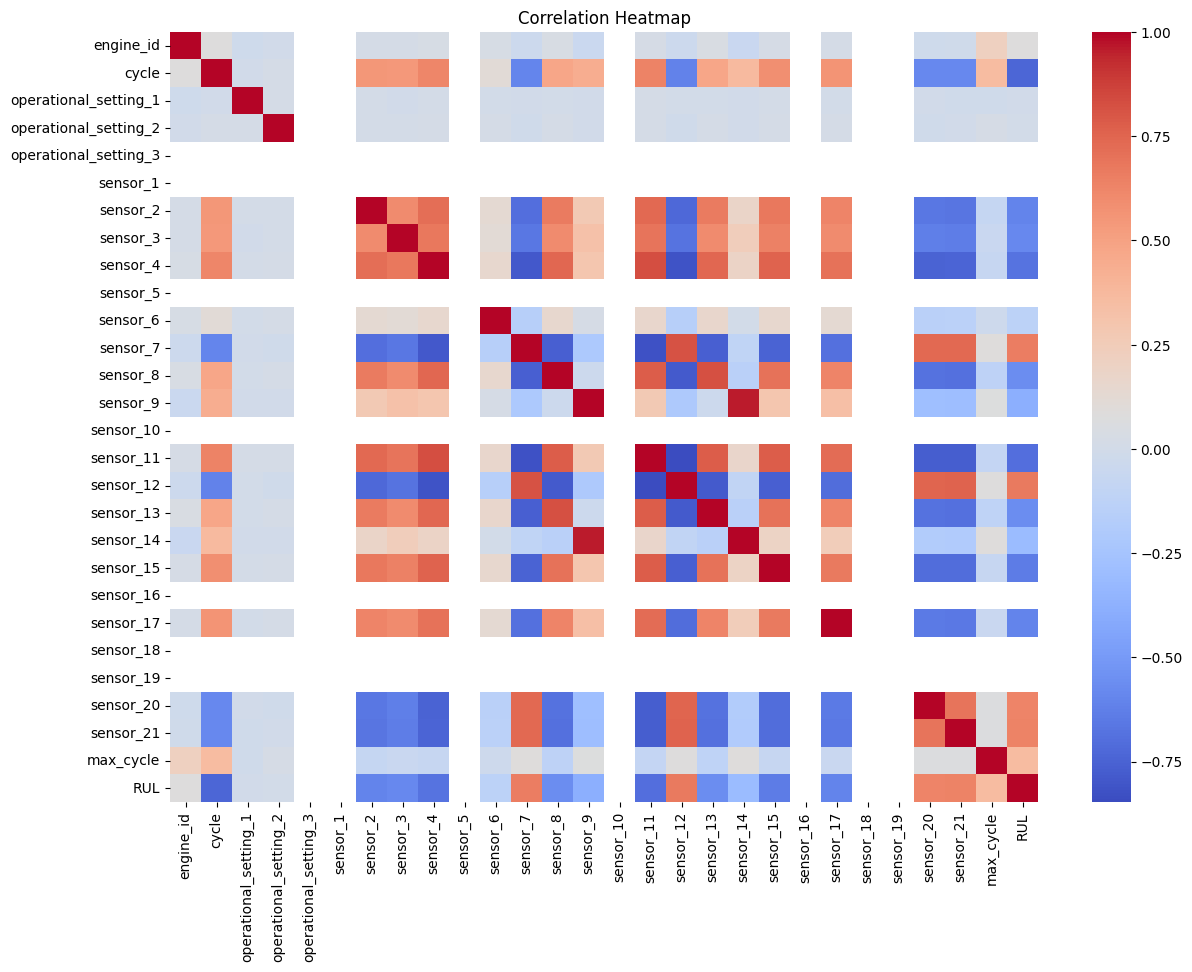

In [21]:
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## EDA Summary

### Key Findings

1. No missing values were found.

2. Constant sensors identified:
   - operational_setting_3
   - sensor_1
   - sensor_5
   - sensor_10
   - sensor_16
   - sensor_18
   - sensor_19

3. Strong positive correlation with RUL:
   - sensor_12
   - sensor_7
   - sensor_21
   - sensor_20

4. Strong negative correlation with RUL:
   - sensor_11
   - sensor_4
   - sensor_15
   - sensor_2

5. Constant sensors will be removed before model training.

## Remove Constant Sensors

In [24]:
constant_cols = [
    'operational_setting_3',
    'sensor_1',
    'sensor_5',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

In [25]:
df_clean = df.drop(columns=constant_cols)

print(df_clean.shape)

(20631, 21)


## Feature Selection

In [40]:
selected_features = [
    'cycle',
    'sensor_2',
    'sensor_3',
    'sensor_4',
    'sensor_7',
    'sensor_8',
    'sensor_11',
    'sensor_12',
    'sensor_13',
    'sensor_15',
    'sensor_17',
    'sensor_20',
    'sensor_21'
]

In [41]:
print("Selected Features:")
for feature in selected_features:
    print(feature)

Selected Features:
cycle
sensor_2
sensor_3
sensor_4
sensor_7
sensor_8
sensor_11
sensor_12
sensor_13
sensor_15
sensor_17
sensor_20
sensor_21


In [42]:
X = df_clean[selected_features]

y = df_clean['RUL']

In [43]:
print(X.shape)

(20631, 13)


## Feature Scaling

In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [45]:
X_scaled[:5]

array([[0.        , 0.18373494, 0.40680183, 0.30975692, 0.72624799,
        0.24242424, 0.36904762, 0.63326226, 0.20588235, 0.36398615,
        0.33333333, 0.71317829, 0.7246617 ],
       [0.00277008, 0.28313253, 0.4530194 , 0.35263336, 0.62801932,
        0.21212121, 0.38095238, 0.76545842, 0.27941176, 0.41131204,
        0.33333333, 0.66666667, 0.73101353],
       [0.00554017, 0.34337349, 0.36952256, 0.37052667, 0.71014493,
        0.27272727, 0.25      , 0.79530917, 0.22058824, 0.35744517,
        0.16666667, 0.62790698, 0.62137531],
       [0.00831025, 0.34337349, 0.25615871, 0.33119514, 0.74074074,
        0.31818182, 0.16666667, 0.8891258 , 0.29411765, 0.16660254,
        0.33333333, 0.57364341, 0.66238608],
       [0.01108033, 0.34939759, 0.25746675, 0.40462525, 0.66827697,
        0.24242424, 0.25595238, 0.74626866, 0.23529412, 0.40207772,
        0.41666667, 0.58914729, 0.70450152]])

In [46]:
print(X_scaled.min())
print(X_scaled.max())

0.0
1.0


## Train Test Split

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (16504, 13)
Testing Set Shape: (4127, 13)


## Data Preprocessing Summary

### Completed Tasks

- Removed constant sensors.
- Selected important sensor features.
- Applied MinMax normalization.
- Split data into training and testing datasets.

### Result

The dataset is now ready for machine learning model training.